# GP-GLLVM — recovering the kernel lengthscale **and** the loadings (composite ZQE)

The estimator (see `gp_fit.py`), mirroring the GLLVM ZQE recipe:

- latent is the **white** $\varepsilon$; the kernel lives in the **decoder**:
  $\varepsilon \to z=L(\ell)\varepsilon \to \eta=Wz+b$. So $\ell$ is in $\eta$ and gets
  gradients by backprop.
- the **encoder is pure no-grad imputation**: per-obs MAP $\to \hat Z$, then whiten
  $\hat\varepsilon=L(\ell)^{-1}\hat Z$. Because $\hat\varepsilon$ is detached, the
  $L(\ell)$ reused in the decoder ($\eta=W\,L(\ell)\,\hat\varepsilon+b$) does **not**
  cancel → $\ell$ is identified.
- plain centered ZQE $-(m_1-m_2)$; fantasies are **K-blocks** (white → correlate →
  Poisson), so every step is $O(K^3)$ with $K\approx15$ — never the full $n\times n$.

Goal (as requested): recover the **lengthscale** and the **loadings** — not $z$ itself.

In [1]:
import sys, os, numpy as np, torch, matplotlib.pyplot as plt
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")) if "__file__" in globals() else ".")
from gp_gllvm import GPGLLVM
from gp_fit import fit_gp_zqe
from gllvm.autofit import procrustes_error, orthogonal_align
torch.set_default_dtype(torch.float64)
plt.rcParams.update({"figure.dpi": 110})

Q, P, KVAR = 2, 30, 1.0
K = 15; tb = torch.linspace(0.0, 10.0, K)        # fixed block geometry
ELL0 = 2.0
gp0 = GPGLLVM(Q, P, lengthscale=ELL0, kernel_var=KVAR, wz_scale=0.7, seed=0)
W0 = gp0.wz.detach().clone()
with torch.no_grad():
    Yd, _, _ = gp0.sample_batch(tb, R=400, seed=1)   # 400 K-blocks of data
print(f"true lengthscale={ELL0}  q={Q} p={P}  block K={K}  data blocks={len(Yd)}")
res = fit_gp_zqe(Yd, tb, Q, kernel_var=KVAR, lengthscale_init=1.0, steps=1500,
                 true_W=W0, verbose=True)
print(f"lengthscale: true {ELL0} -> est {res['lengthscale']:.3f}")
print(f"loadings procrustes = {procrustes_error(W0, res['W']):.3f}  "
      f"(||W_est||={res['W'].norm():.2f} vs true {W0.norm():.2f})")

true lengthscale=2.0  q=2 p=30  block K=15  data blocks=400


  step  500  ell=1.989  loss=+0.3304  procrustes=0.047


  step 1000  ell=2.010  loss=+0.0044  procrustes=0.039


  step 1500  ell=1.975  loss=-0.1210  procrustes=0.043


lengthscale: true 2.0 -> est 1.978
loadings procrustes = 0.043  (||W_est||=5.78 vs true 5.78)


## Convergence: $\ell$ and the loadings

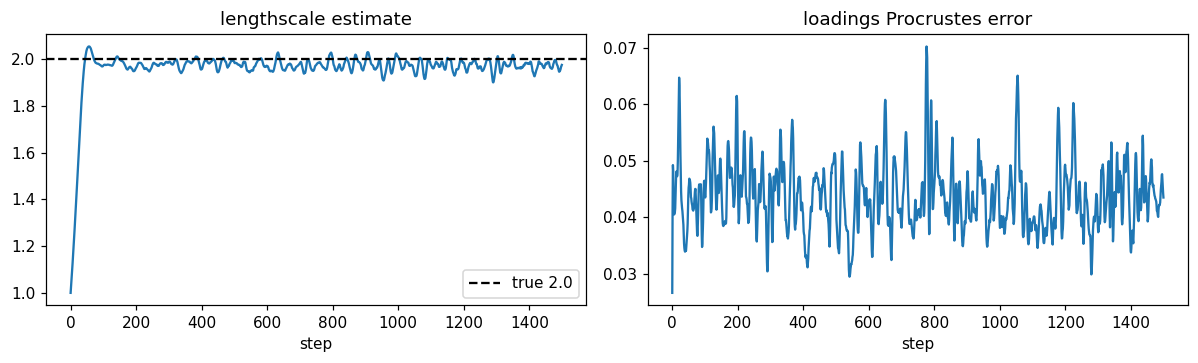

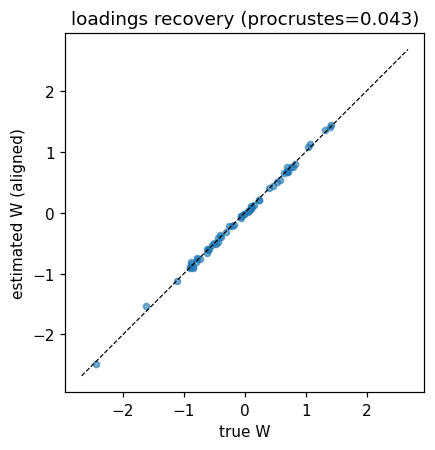

In [2]:
h = res["history"]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(h["ell"]); ax[0].axhline(ELL0, color="k", ls="--", label=f"true {ELL0}")
ax[0].set_title("lengthscale estimate"); ax[0].set_xlabel("step"); ax[0].legend()
ax[1].plot(h["procrustes"]); ax[1].set_title("loadings Procrustes error"); ax[1].set_xlabel("step")
plt.tight_layout(); plt.show()

# loadings: true vs aligned estimate
Wal = (res["W"] @ orthogonal_align(W0, res["W"])).numpy()
plt.figure(figsize=(4.2, 4.2))
plt.scatter(W0.numpy().ravel(), Wal.ravel(), s=16, alpha=.6)
lim = 1.1*np.abs(W0.numpy()).max(); plt.plot([-lim,lim],[-lim,lim],"k--",lw=.8)
plt.gca().set_aspect("equal"); plt.xlabel("true W"); plt.ylabel("estimated W (aligned)")
plt.title(f"loadings recovery (procrustes={procrustes_error(W0,res['W']):.3f})")
plt.tight_layout(); plt.show()

## Lengthscale recovery across true values

Fit from the same (wrong) init `1.5` for several true lengthscales.

In [3]:
rows = []
for ell0 in [1.0, 2.0, 3.0]:
    g = GPGLLVM(Q, P, lengthscale=ell0, kernel_var=KVAR, wz_scale=0.7, seed=0)
    Wt = g.wz.detach().clone()
    with torch.no_grad():
        Y, _, _ = g.sample_batch(tb, R=400, seed=1)
    r = fit_gp_zqe(Y, tb, Q, kernel_var=KVAR, lengthscale_init=1.5, steps=1500, seed=0)
    rows.append((ell0, r["lengthscale"], procrustes_error(Wt, r["W"])))
import pandas as pd
df = pd.DataFrame(rows, columns=["true_ell", "est_ell", "loadings_procrustes"]).round(3)
display(df)

,true_ell,est_ell,loadings_procrustes
0,1.0,1.021,0.028
1,2.0,1.958,0.038
2,3.0,3.142,0.051


## Takeaway

Composite ZQE on K-blocks recovers **both** the GP lengthscale and the loadings — the
kernel parameter is identified because it sits in the decoder ($\eta=W L(\ell)\hat\varepsilon+b$)
with a detached imputed $\hat\varepsilon$, exactly as the GLLVM recipe handles $W,b$.
Every step touches only $K\times K$ blocks, so this scales to $n$ where the full GP
likelihood is hopeless — the basis for the "fast GP-GLLVM that likelihood methods
can't fit" result.